In [1]:
%pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------------- -- 1.6/1.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 7.3 MB/s  0:00:00

   ----------------------------------------  0/10 [peewee]
   ----------------------------------------  0/10 [peewee]
   ----------------------------------------  0/10 [peewee]
   ----------------------------------------  0/10 [peewee]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   -------- -------------------------------  2/10 [websockets]
   ------------ -------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as fy
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [5]:
data = fy.download('AAPL', start = '2018-01-01', end = '2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [6]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267071,40.276423,39.565798,39.776182,102223600
2018-01-03,40.260063,40.802382,40.196951,40.330191,118071600
2018-01-04,40.447071,40.549925,40.225002,40.332529,89738400
2018-01-05,40.907578,40.994067,40.451751,40.542916,94640000
2018-01-08,40.755623,41.050156,40.657442,40.755623,82271200


In [8]:
dataset = data['Close'].dropna().values.reshape(-1,1)

In [9]:
scalar = MinMaxScaler(feature_range=(0,1))
scaled_data = scalar.fit_transform(dataset)

In [12]:
X = []
Y = []

In [13]:
for i in range(60,len(scaled_data)):
    X.append(scaled_data[i-60:i,0])
    Y.append(scaled_data[i,0])


In [14]:
X, Y = np.array(X).reshape(-1,60,1), np.array(Y)

In [15]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:] 
Y_train, Y_test = Y[:split], Y[split:]

In [16]:
model = Sequential([
    SimpleRNN(50, input_shape = (60,1)),
    Dense(1)
])

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [18]:
model.fit(X_train, Y_train, epochs=5,batch_size=32, validation_data=(X_train, Y_train))

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0171 - val_loss: 8.3070e-04
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.5441e-04 - val_loss: 6.9850e-04
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8726e-04 - val_loss: 9.2943e-04
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.3977e-04 - val_loss: 6.5403e-04
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.1881e-04 - val_loss: 6.6606e-04


In [20]:
pred = scalar.inverse_transform(model.predict(X_test))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [21]:
actual = scalar.inverse_transform(Y_test.reshape(-1,1))

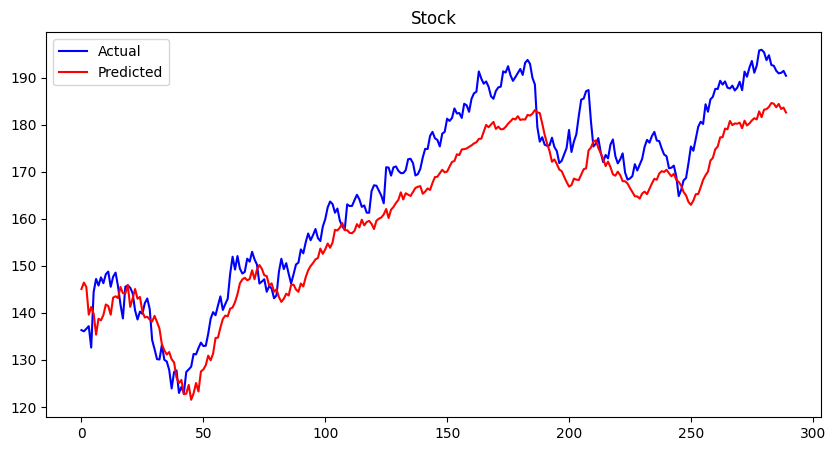

In [24]:
plt.figure(figsize=(10,5))
plt.plot(actual,color='blue',label = 'Actual')
plt.plot(pred,color = 'red', label = 'Predicted')
plt.title('Stock')
plt.legend()
plt.show()

In [25]:
actual

array([[136.33605957],
       [136.07058716],
       [136.60159302],
       [137.17190552],
       [132.61920166],
       [144.41889954],
       [147.20166016],
       [145.80534363],
       [147.53596497],
       [146.30683899],
       [148.20465088],
       [148.76512146],
       [145.53988647],
       [147.67362976],
       [148.54882812],
       [145.63821411],
       [141.81312561],
       [138.81401062],
       [145.55950928],
       [145.8348999 ],
       [145.34320068],
       [144.18289185],
       [140.5249939 ],
       [138.58787537],
       [140.26934814],
       [139.78752136],
       [142.07861328],
       [143.04225159],
       [140.82000732],
       [134.2219696 ],
       [132.26515198],
       [130.16090393],
       [130.09205627],
       [133.18946838],
       [130.02322388],
       [129.65939331],
       [127.8599472 ],
       [123.93653107],
       [127.44696808],
       [127.76158142],
       [122.98271179],
       [124.25119781],
       [122.93354034],
       [127

In [26]:
pred

array([[145.06831 ],
       [146.43332 ],
       [145.48062 ],
       [139.61322 ],
       [141.23727 ],
       [139.82036 ],
       [135.37746 ],
       [138.74442 ],
       [138.41292 ],
       [139.52803 ],
       [141.77592 ],
       [141.4527  ],
       [139.60445 ],
       [143.23715 ],
       [143.52098 ],
       [143.15512 ],
       [145.48949 ],
       [144.18848 ],
       [144.12569 ],
       [145.9351  ],
       [141.27428 ],
       [143.04518 ],
       [145.06795 ],
       [143.00383 ],
       [143.37027 ],
       [140.20717 ],
       [139.01935 ],
       [139.17433 ],
       [138.58405 ],
       [138.1404  ],
       [139.35878 ],
       [138.04935 ],
       [136.64836 ],
       [133.29909 ],
       [132.03656 ],
       [131.15276 ],
       [131.66911 ],
       [130.12183 ],
       [129.46777 ],
       [126.23957 ],
       [125.08796 ],
       [125.75054 ],
       [122.71479 ],
       [122.83268 ],
       [124.68842 ],
       [121.53145 ],
       [122.893394],
       [125.0